In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math as math

In [ ]:
atoms = 2000
Temp = 15000
kb = 1.38e-23
NA = 6.022e23
MSI = 28.0855/NA #use cgs system
angle = 0.3 #radians
sinangle = math.sin(angle)
cosangle = math.cos(angle)


def trajtoarr(filename, dt,atoms=2000):
    timeflag =False
    atomflag=False
    count = 0
    atomlist = []
    tempatomlist=[]
    timestep=0
    with open(filename, 'r') as file:
        for line in file:
            if "ITEM" in line:
                if "ITEM: TIMESTEP" in line:
                    count += 1
                    timeflag = True
                    atomflag=False
                    tempatomlist.append(float(dt*timestep))
                    atomlist.append(tempatomlist)
                    tempatomlist=[]
                elif "ITEM: ATOMS id type vx vy vz" in line:
                    atomflag = True
                    timeflag=False
                else:
                    timeflag = False
                    atomflag = False
            if timeflag and ("ITEM" not in line):
                timestep = float(line.strip())
            if atomflag and ("ITEM" not in line):
                vz = float(line.strip().split(" ")[-1])
                vy = float(line.strip().split(" ")[-2])
                tempatomlist.append(sinangle*vy+cosangle*vz)
                count += 1
    tempatomlist.append(float(dt*timestep))
    atomlist.append(tempatomlist)
    atomlist.pop()
    atomlist.pop(0)
    atomlist.pop()
    atomarr = np.array(atomlist)
    return atomarr
def logtoarr(filename):
    startlogstr = "   Step          Time           Temp         c_tempH        c_tempSi        TotEng         PotEng         KinEng         Press           v_k0           v_dt        v_collfreq       v_ccs "
    endlogstr = "Loop time of "
    templist=[]
    dataflag=False
    with open(filename, 'r') as file:
        for line in file:
            if "error:" in list(filter(None, line.split(" "))):
                break
            if dataflag:
                dataline = list(filter(None, line.split(" ")))
                dataline[-1] = dataline[-1][:-1]
                dataline = list(filter(None, dataline))
                templist.append(dataline)
            if startlogstr in line:
                dataflag=True
                templist=[]
            if endlogstr in line:
                dataflag=False

    templist.pop()
    templist.pop()
    templist.pop()
    templist.pop()
    templist.pop()
    templist.pop(0)    # print(templist
    return np.array(templist,dtype=np.float64)


runlist = ["run10_15","run10_15b","run10_17","run10_18","run10_19"]
dropdict = {"run10_15":[[0,0],[0,1],[0,2],[1,2],[3,2],[4,2],[5,0],[5,1],[5,2],[5,3]]
}
thermdict = {"run10_15":801,"run10_15b":801,"run10_17":801,"run10_18":801,"run10_19":201}
veldict = {"run10_15":[2e7,3e7,4e7,5e7,6e7,8e7],"run10_15b":[1e2,1e3,1e4,1e5,1e6,1e7,1e8],"run10_17":[1.5e7,2e6,2.5e7,3e6,3.5e7,4.5e7,6e6,8e6],"run10_18":[],"run10_19":201}
for k in range(len(runlist)):
    run = runlist[k]
    print(run)
    thermsteps =thermdict[run]
    velarr = np.array([1e2,1e3,1e4,1e5,1e6,1e7,1e8])
    casearr = np.array([0,1,2,3])
    folder = "../dataarchive/"+run
    for i in range(len(velarr)):
        for j in range(len(casearr)):
            if  [i,j] not in []:
                print(i,j)
                vel = velarr[i]
                case = casearr[j]
                datai = logtoarr(folder+"/unforcedslumlogvel_v{:.1e}_c{}.txt".format(vel,case))
                dt = (datai[1,1]-datai[0,1])/100
                trajarr = trajtoarr(folder+"/trajvel_v{:.1e}_c{}.txt".format(vel,case),dt,atoms=atoms)
                np.savetxt("log_v{:.1}_c{}.np".format(vel,case),datai)
                np.savetxt("force_v{:.1}_c{}.np".format(vel,case),trajarr)





0 0
[['100', '4.959026e-13', '5001.4698', '5002.3445', '4785.1889', '5.7983155e-07', '5.9864911e-08', '5.1996664e-07', '4660224.7', '1155861.6', '4.959026e-15', '1.1011056e+09', '1.39332e-16'], ['200', '9.918052e-13', '4994.939', '4995.8142', '4778.5281', '5.7908677e-07', '5.9799085e-08', '5.1928769e-07', '4654439.1', '1155861.6', '4.959026e-15', '1.1011056e+09', '1.39332e-16'], ['300', '1.4877078e-12', '4988.45', '4989.3366', '4769.187', '5.7839668e-07', '5.9783613e-08', '5.1861307e-07', '4648962.8', '1155861.6', '4.959026e-15', '1.1011056e+09', '1.39332e-16'], ['400', '1.9836104e-12', '5002.1868', '5003.0746', '4782.6324', '5.7983836e-07', '5.9797167e-08', '5.2004119e-07', '4660316.9', '1155861.6', '4.959026e-15', '1.1011056e+09', '1.39332e-16'], ['500', '2.479513e-12', '5006.3421', '5007.2294', '4786.8958', '5.8025457e-07', '5.9781386e-08', '5.2047318e-07', '4663650.8', '1155861.6', '4.959026e-15', '1.1011056e+09', '1.39332e-16'], ['600', '2.9754156e-12', '5000.9285', '5001.8238', '

IndexError: pop from empty list

# plot 

0 3
20000000.0
[[1.0000000e+02 4.7724823e-16 9.9280996e+04 9.9290476e+04 9.6959473e+04
  1.9370104e-05 9.0485771e-06 1.0321527e-05 1.9394414e+13 1.3911130e+08
  4.7724823e-18 4.4510551e+14 2.8749200e-17]
 [2.0000000e+02 9.5449646e-16 1.0009793e+05 1.0010028e+05 9.9561726e+04
  1.9417370e-05 9.0109115e-06 1.0406458e-05 1.9412247e+13 1.3911130e+08
  4.7724823e-18 4.4510551e+14 2.8749200e-17]
 [3.0000000e+02 1.4317447e-15 1.0114472e+05 1.0114398e+05 1.0137957e+05
  1.9395519e-05 8.8802342e-06 1.0515285e-05 1.9399132e+13 1.3911130e+08
  4.7724823e-18 4.4510551e+14 2.8749200e-17]
 [4.0000000e+02 1.9089929e-15 1.0118578e+05 1.0118267e+05 1.0201423e+05
  1.9307137e-05 8.7875832e-06 1.0519554e-05 1.9326289e+13 1.3911130e+08
  4.7724823e-18 4.4510551e+14 2.8749200e-17]
 [5.0000000e+02 2.3862412e-15 1.0074850e+05 1.0074397e+05 1.0193286e+05
  1.9210080e-05 8.7359873e-06 1.0474093e-05 1.9243314e+13 1.3911130e+08
  4.7724823e-18 4.4510551e+14 2.8749200e-17]
 [6.0000000e+02 2.8634894e-15 1.0018186e

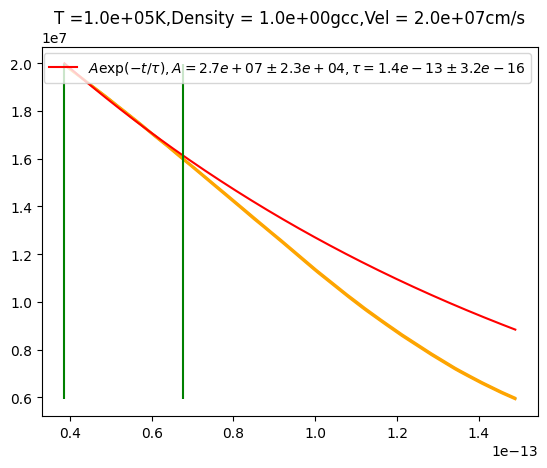

1 0
30000000.0
[[1.0000000e+02 1.7726870e-14 5.0000601e+03 5.0009260e+03 4.7859817e+03
  5.7988603e-07 6.0065943e-08 5.1982009e-07 4.6600091e+06 1.1558616e+06
  1.7726870e-16 1.2198953e+05 6.5190300e-22]
 [2.0000000e+02 3.5453740e-14 4.9999642e+03 5.0008296e+03 4.7860156e+03
  5.7986743e-07 6.0057311e-08 5.1981012e-07 4.6599003e+06 1.1558616e+06
  1.7726870e-16 1.2198953e+05 6.5190300e-22]
 [3.0000000e+02 5.3180609e-14 4.9994398e+03 5.0003047e+03 4.7856170e+03
  5.7980178e-07 6.0046176e-08 5.1975560e-07 4.6594252e+06 1.1558616e+06
  1.7726870e-16 1.2198953e+05 6.5190300e-22]
 [4.0000000e+02 7.0907479e-14 4.9995069e+03 5.0003719e+03 4.7856689e+03
  5.7980207e-07 6.0039491e-08 5.1976258e-07 4.6594495e+06 1.1558616e+06
  1.7726870e-16 1.2198953e+05 6.5190300e-22]
 [5.0000000e+02 8.8634349e-14 5.0008463e+03 5.0017116e+03 4.7868937e+03
  5.7993474e-07 6.0032923e-08 5.1990182e-07 4.6605242e+06 1.1558616e+06
  1.7726870e-16 1.2198953e+05 6.5190300e-22]
 [6.0000000e+02 1.0636122e-13 5.0017399e

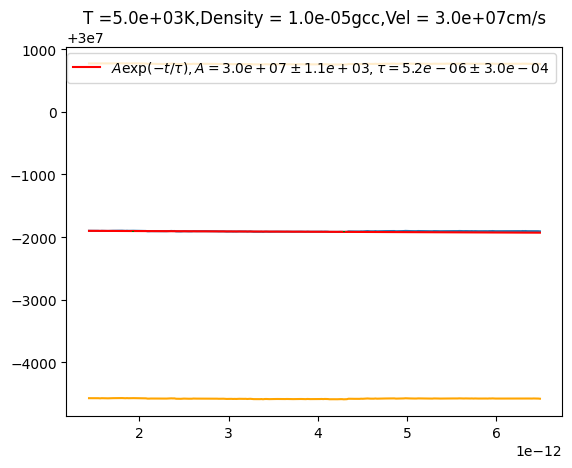

1 1
30000000.0
[[1.0000000e+02 3.8301576e-16 5.1206103e+03 5.1214459e+03 4.9141725e+03
  1.3781401e-06 8.4578732e-07 5.3235282e-07 1.7636540e+12 3.3483091e+08
  3.8301576e-18 3.4781170e+13 1.8586800e-18]
 [2.0000000e+02 7.6603152e-16 5.3992241e+03 5.4000357e+03 5.1989183e+03
  1.3696307e-06 8.0831245e-07 5.6131828e-07 1.7479555e+12 3.3483091e+08
  3.8301576e-18 3.4781170e+13 1.8586800e-18]
 [3.0000000e+02 1.1490473e-15 5.6994458e+03 5.7006767e+03 5.3944060e+03
  1.3518137e-06 7.5928350e-07 5.9253016e-07 1.7206227e+12 3.3483091e+08
  3.8301576e-18 3.4781170e+13 1.8586800e-18]
 [4.0000000e+02 1.5320630e-15 5.9213661e+03 5.9233028e+03 5.4399101e+03
  1.3251650e-06 7.0956337e-07 6.1560161e-07 1.6839440e+12 3.3483091e+08
  3.8301576e-18 3.4781170e+13 1.8586800e-18]
 [5.0000000e+02 1.9150788e-15 6.0200867e+03 6.0227292e+03 5.3621242e+03
  1.2916561e-06 6.6579127e-07 6.2586487e-07 1.6413028e+12 3.3483091e+08
  3.8301576e-18 3.4781170e+13 1.8586800e-18]
 [6.0000000e+02 2.2980946e-15 6.0010828e

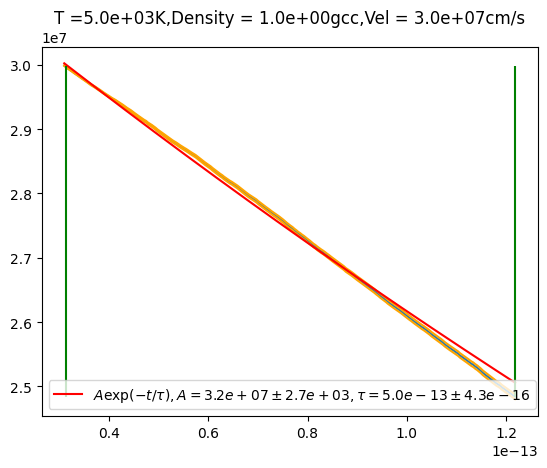

1 3
30000000.0
[[1.0000000e+02 3.4078730e-16 9.9531123e+04 9.9543822e+04 9.6404659e+04
  1.9361949e-05 9.0144179e-06 1.0347531e-05 1.9405616e+13 1.3911130e+08
  3.4078730e-18 9.2899430e+13 4.3296500e-18]
 [2.0000000e+02 6.8157460e-16 9.9547941e+04 9.9553496e+04 9.8208143e+04
  1.9409755e-05 9.0604752e-06 1.0349279e-05 1.9409647e+13 1.3911130e+08
  3.4078730e-18 9.2899430e+13 4.3296500e-18]
 [3.0000000e+02 1.0223619e-15 1.0052883e+05 1.0053061e+05 1.0013481e+05
  1.9444806e-05 8.9935505e-06 1.0451256e-05 1.9434086e+13 1.3911130e+08
  3.4078730e-18 9.2899430e+13 4.3296500e-18]
 [4.0000000e+02 1.3631492e-15 1.0094550e+05 1.0094512e+05 1.0108936e+05
  1.9393086e-05 8.8985128e-06 1.0494573e-05 1.9396812e+13 1.3911130e+08
  3.4078730e-18 9.2899430e+13 4.3296500e-18]
 [5.0000000e+02 1.7039365e-15 1.0089817e+05 1.0089602e+05 1.0148528e+05
  1.9311695e-05 8.8220418e-06 1.0489653e-05 1.9332067e+13 1.3911130e+08
  3.4078730e-18 9.2899430e+13 4.3296500e-18]
 [6.0000000e+02 2.0447238e-15 1.0058518e

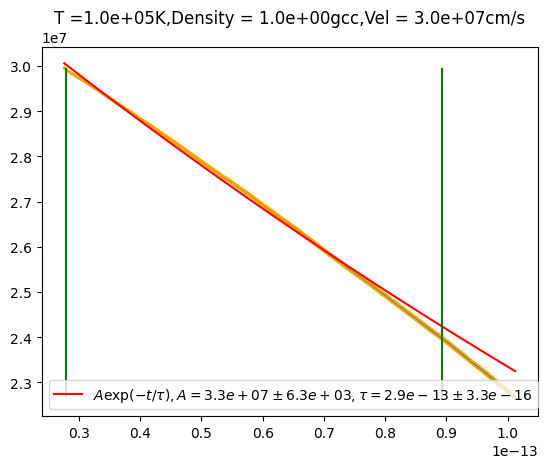

2 0
40000000.0
[[1.0000000e+02 1.3415027e-14 5.0000255e+03 5.0008914e+03 4.7859473e+03
  5.7988591e-07 6.0069418e-08 5.1981649e-07 4.6599901e+06 1.1558616e+06
  1.3415027e-16 4.8640135e+04 1.9702700e-22]
 [2.0000000e+02 2.6830054e-14 5.0000738e+03 5.0009396e+03 4.7860053e+03
  5.7987975e-07 6.0058235e-08 5.1982151e-07 4.6599921e+06 1.1558616e+06
  1.3415027e-16 4.8640135e+04 1.9702700e-22]
 [3.0000000e+02 4.0245082e-14 4.9996869e+03 5.0005520e+03 4.7858014e+03
  5.7983544e-07 6.0054154e-08 5.1978129e-07 4.6596607e+06 1.1558616e+06
  1.3415027e-16 4.8640135e+04 1.9702700e-22]
 [4.0000000e+02 5.3660109e-14 4.9995923e+03 5.0004572e+03 4.7857628e+03
  5.7981734e-07 6.0045887e-08 5.1977145e-07 4.6595493e+06 1.1558616e+06
  1.3415027e-16 4.8640135e+04 1.9702700e-22]
 [5.0000000e+02 6.7075136e-14 5.0003373e+03 5.0012023e+03 4.7864690e+03
  5.7988952e-07 6.0040621e-08 5.1984890e-07 4.6601379e+06 1.1558616e+06
  1.3415027e-16 4.8640135e+04 1.9702700e-22]
 [6.0000000e+02 8.0490163e-14 5.0012131e

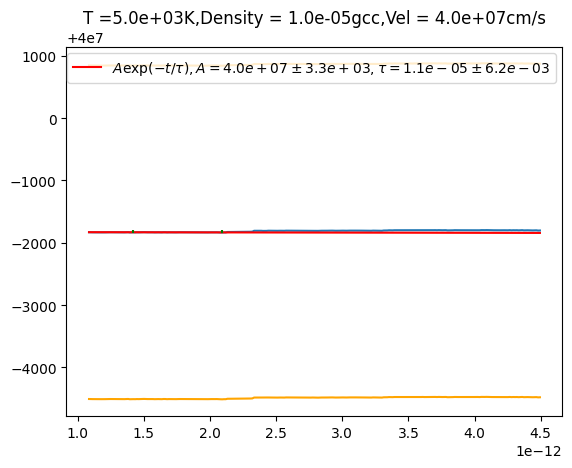

2 1
40000000.0
[[1.0000000e+02 2.8985190e-16 5.0681080e+03 5.0689789e+03 4.8528109e+03
  1.3786804e-06 8.5178583e-07 5.2689453e-07 1.7654271e+12 3.3483091e+08
  2.8985190e-18 1.5240643e+13 6.1735400e-19]
 [2.0000000e+02 5.7970380e-16 5.2340920e+03 5.2348675e+03 5.0427241e+03
  1.3729082e-06 8.2875756e-07 5.4415069e-07 1.7555727e+12 3.3483091e+08
  2.8985190e-18 1.5240643e+13 6.1735400e-19]
 [3.0000000e+02 8.6955570e-16 5.4333531e+03 5.4342260e+03 5.2177352e+03
  1.3606153e-06 7.9574890e-07 5.6486642e-07 1.7376414e+12 3.3483091e+08
  2.8985190e-18 1.5240643e+13 6.1735400e-19]
 [4.0000000e+02 1.1594076e-15 5.6141920e+03 5.6154242e+03 5.3088027e+03
  1.3417105e-06 7.5804359e-07 5.8366694e-07 1.7123501e+12 3.3483091e+08
  2.8985190e-18 1.5240643e+13 6.1735400e-19]
 [5.0000000e+02 1.4492595e-15 5.7398703e+03 5.7416168e+03 5.3059167e+03
  1.3169224e-06 7.2018958e-07 5.9673281e-07 1.6811130e+12 3.3483091e+08
  2.8985190e-18 1.5240643e+13 6.1735400e-19]
 [6.0000000e+02 1.7391114e-15 5.7945816e

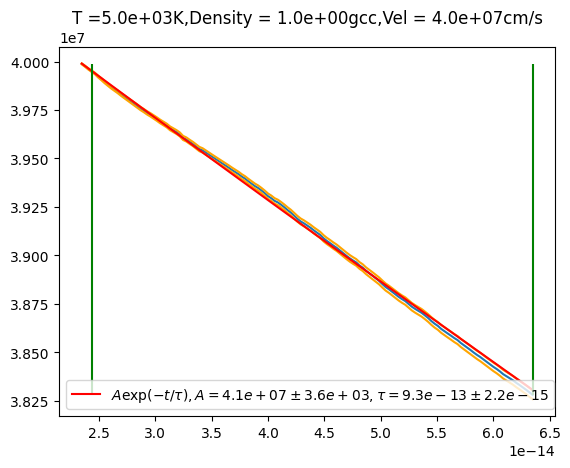

2 2
40000000.0
[[1.0000000e+02 1.2310830e-14 1.0001133e+05 1.0002852e+05 9.5759808e+04
  1.4303613e-05 3.9061583e-06 1.0397454e-05 1.0890637e+08 6.2365638e+05
  1.2310830e-16 8.1558002e+08 2.9732300e-18]
 [2.0000000e+02 2.4621659e-14 9.9971527e+04 9.9988732e+04 9.5718098e+04
  1.4297698e-05 3.9043809e-06 1.0393317e-05 1.0886678e+08 6.2365638e+05
  1.2310830e-16 8.1558002e+08 2.9732300e-18]
 [3.0000000e+02 3.6932489e-14 9.9875117e+04 9.9892327e+04 9.5620397e+04
  1.4286013e-05 3.9027197e-06 1.0383294e-05 1.0878127e+08 6.2365638e+05
  1.2310830e-16 8.1558002e+08 2.9732300e-18]
 [4.0000000e+02 4.9243319e-14 9.9965855e+04 9.9983092e+04 9.5704607e+04
  1.4293729e-05 3.9010023e-06 1.0392727e-05 1.0884754e+08 6.2365638e+05
  1.2310830e-16 8.1558002e+08 2.9732300e-18]
 [5.0000000e+02 6.1554148e-14 1.0016642e+05 1.0018376e+05 9.5879596e+04
  1.4312851e-05 3.8992729e-06 1.0413578e-05 1.0900324e+08 6.2365638e+05
  1.2310830e-16 8.1558002e+08 2.9732300e-18]
 [6.0000000e+02 7.3864978e-14 1.0007366e

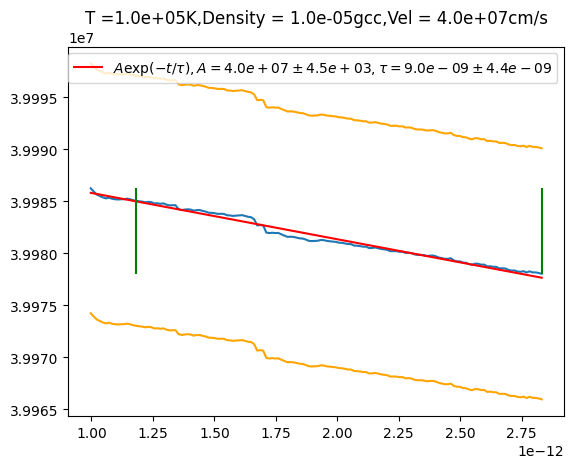

2 3
40000000.0
[[1.0000000e+02 2.6501174e-16 9.9695468e+04 9.9709833e+04 9.6152328e+04
  1.9357667e-05 8.9930497e-06 1.0364617e-05 1.9412023e+13 1.3911130e+08
  2.6501174e-18 3.1982637e+13 1.1659400e-18]
 [2.0000000e+02 5.3002349e-16 9.9500666e+04 9.9509013e+04 9.7462681e+04
  1.9401307e-05 9.0569419e-06 1.0344365e-05 1.9413308e+13 1.3911130e+08
  2.6501174e-18 3.1982637e+13 1.1659400e-18]
 [3.0000000e+02 7.9503523e-16 1.0002613e+05 1.0003014e+05 9.9073073e+04
  1.9445495e-05 9.0465020e-06 1.0398993e-05 1.9434574e+13 1.3911130e+08
  2.6501174e-18 3.1982637e+13 1.1659400e-18]
 [4.0000000e+02 1.0600470e-15 1.0064194e+05 1.0064343e+05 1.0032022e+05
  1.9446664e-05 8.9836490e-06 1.0463015e-05 1.9435778e+13 1.3911130e+08
  2.6501174e-18 3.1982637e+13 1.1659400e-18]
 [5.0000000e+02 1.3250587e-15 1.0074458e+05 1.0074441e+05 1.0083597e+05
  1.9382828e-05 8.9091430e-06 1.0473685e-05 1.9388444e+13 1.3911130e+08
  2.6501174e-18 3.1982637e+13 1.1659400e-18]
 [6.0000000e+02 1.5900705e-15 1.0065729e

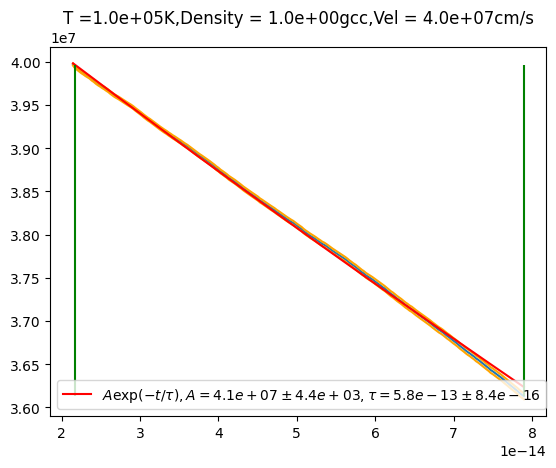

3 0
50000000.0
[[1.0000000e+02 1.0790396e-14 5.0000049e+03 5.0008708e+03 4.7859224e+03
  5.7988566e-07 6.0071317e-08 5.1981435e-07 4.6599785e+06 1.1558616e+06
  1.0790396e-16 2.4079074e+04 7.8532600e-23]
 [2.0000000e+02 2.1580793e-14 5.0000977e+03 5.0009636e+03 4.7860153e+03
  5.7988648e-07 6.0062487e-08 5.1982399e-07 4.6600299e+06 1.1558616e+06
  1.0790396e-16 2.4079074e+04 7.8532600e-23]
 [3.0000000e+02 3.2371189e-14 4.9998715e+03 5.0007370e+03 4.7858758e+03
  5.7985770e-07 6.0057220e-08 5.1980048e-07 4.6598219e+06 1.1558616e+06
  1.0790396e-16 2.4079074e+04 7.8532600e-23]
 [4.0000000e+02 4.3161585e-14 4.9996368e+03 5.0005019e+03 4.7857743e+03
  5.7982785e-07 6.0051761e-08 5.1977608e-07 4.6596083e+06 1.1558616e+06
  1.0790396e-16 2.4079074e+04 7.8532600e-23]
 [5.0000000e+02 5.3951982e-14 5.0000340e+03 5.0008990e+03 4.7861857e+03
  5.7986311e-07 6.0045729e-08 5.1981738e-07 4.6599123e+06 1.1558616e+06
  1.0790396e-16 2.4079074e+04 7.8532600e-23]
 [6.0000000e+02 6.4742378e-14 5.0008566e

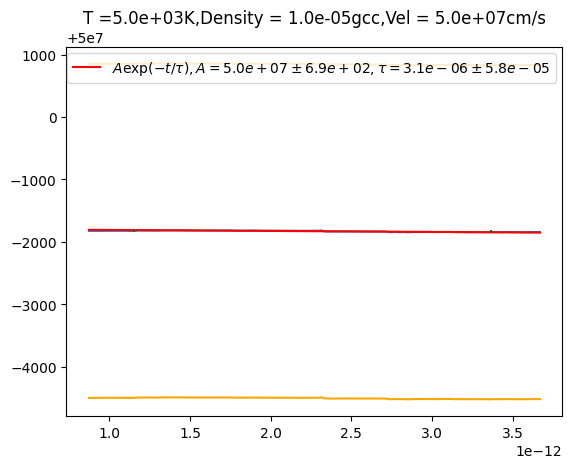

3 1
50000000.0
[[1.0000000e+02 2.3314279e-16 5.0436778e+03 5.0445660e+03 4.8240464e+03
  1.3790476e-06 8.5469293e-07 5.2435471e-07 1.7663588e+12 3.3483091e+08
  2.3314279e-18 7.8957616e+12 2.5751600e-19]
 [2.0000000e+02 4.6628558e-16 5.1505468e+03 5.1513477e+03 4.9528038e+03
  1.3747172e-06 8.3925209e-07 5.3546511e-07 1.7594675e+12 3.3483091e+08
  2.3314279e-18 7.8957616e+12 2.5751600e-19]
 [3.0000000e+02 6.9942837e-16 5.2862611e+03 5.2870394e+03 5.0942384e+03
  1.3656258e-06 8.1605143e-07 5.4957434e-07 1.7467611e+12 3.3483091e+08
  2.3314279e-18 7.8957616e+12 2.5751600e-19]
 [4.0000000e+02 9.3257116e-16 5.4213297e+03 5.4222525e+03 5.1932186e+03
  1.3514575e-06 7.8784107e-07 5.6361644e-07 1.7283629e+12 3.3483091e+08
  2.3314279e-18 7.8957616e+12 2.5751600e-19]
 [5.0000000e+02 1.1657139e-15 5.5325647e+03 5.5337928e+03 5.2281733e+03
  1.3325153e-06 7.5733454e-07 5.7518074e-07 1.7049449e+12 3.3483091e+08
  2.3314279e-18 7.8957616e+12 2.5751600e-19]
 [6.0000000e+02 1.3988567e-15 5.6048229e

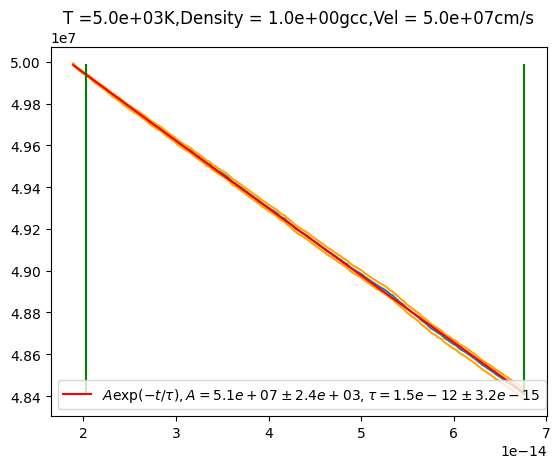

3 3
50000000.0
[[1.0000000e+02 2.1680434e-16 9.9790161e+04 9.9805440e+04 9.6018277e+04
  1.9355325e-05 8.9808641e-06 1.0374461e-05 1.9415582e+13 1.3911130e+08
  2.1680434e-18 1.4379809e+13 4.3046900e-19]
 [2.0000000e+02 4.3360869e-16 9.9617240e+04 9.9627766e+04 9.7034379e+04
  1.9395909e-05 9.0394245e-06 1.0356484e-05 1.9419867e+13 1.3911130e+08
  2.1680434e-18 1.4379809e+13 4.3046900e-19]
 [3.0000000e+02 6.5041303e-16 9.9781869e+04 9.9787949e+04 9.8311051e+04
  1.9435968e-05 9.0623684e-06 1.0373599e-05 1.9431584e+13 1.3911130e+08
  2.1680434e-18 1.4379809e+13 4.3046900e-19]
 [4.0000000e+02 8.6721737e-16 1.0034135e+05 1.0034456e+05 9.9589933e+04
  1.9464328e-05 9.0325637e-06 1.0431765e-05 1.9448679e+13 1.3911130e+08
  2.1680434e-18 1.4379809e+13 4.3046900e-19]
 [5.0000000e+02 1.0840217e-15 1.0053106e+05 1.0053237e+05 1.0025315e+05
  1.9428805e-05 8.9773182e-06 1.0451487e-05 1.9421927e+13 1.3911130e+08
  2.1680434e-18 1.4379809e+13 4.3046900e-19]
 [6.0000000e+02 1.3008261e-15 1.0056193e

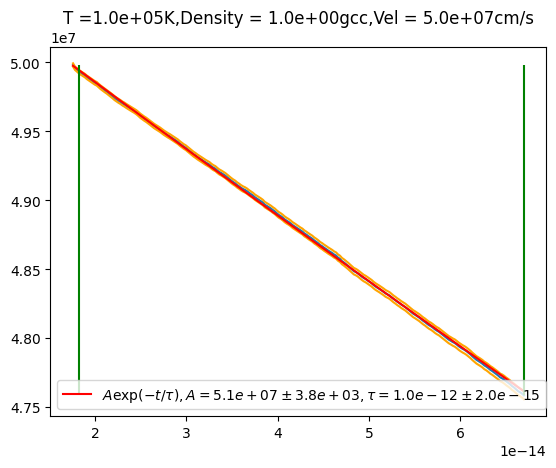

4 0
60000000.0
[[1.0000000e+02 9.0247223e-15 4.9999940e+03 5.0008599e+03 4.7859034e+03
  5.7988521e-07 6.0071999e-08 5.1981321e-07 4.6599690e+06 1.1558616e+06
  9.0247223e-17 1.3626374e+04 3.7194500e-23]
 [2.0000000e+02 1.8049445e-14 5.0000953e+03 5.0009612e+03 4.7860153e+03
  5.7988944e-07 6.0065695e-08 5.1982374e-07 4.6600375e+06 1.1558616e+06
  9.0247223e-17 1.3626374e+04 3.7194500e-23]
 [3.0000000e+02 2.7074167e-14 5.0000126e+03 5.0008784e+03 4.7859484e+03
  5.7987326e-07 6.0058108e-08 5.1981515e-07 4.6599411e+06 1.1558616e+06
  9.0247223e-17 1.3626374e+04 3.7194500e-23]
 [4.0000000e+02 3.6098889e-14 4.9996735e+03 5.0005388e+03 4.7857469e+03
  5.7983707e-07 6.0057171e-08 5.1977990e-07 4.6596610e+06 1.1558616e+06
  9.0247223e-17 1.3626374e+04 3.7194500e-23]
 [5.0000000e+02 4.5123612e-14 4.9998090e+03 5.0006740e+03 4.7859503e+03
  5.7984446e-07 6.0050473e-08 5.1979399e-07 4.6597449e+06 1.1558616e+06
  9.0247223e-17 1.3626374e+04 3.7194500e-23]
 [6.0000000e+02 5.4148334e-14 5.0006143e

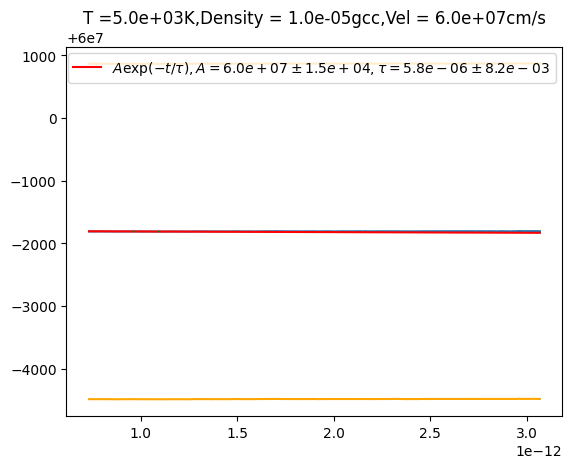

4 1
60000000.0
[[1.0000000e+02 1.9499274e-16 5.0304579e+03 5.0313542e+03 4.8087964e+03
  1.3792947e-06 8.5631437e-07 5.2298033e-07 1.7669084e+12 3.3483091e+08
  1.9499274e-18 4.5819595e+12 1.2506900e-19]
 [2.0000000e+02 3.8998548e-16 5.1032538e+03 5.1040830e+03 4.8983953e+03
  1.3758362e-06 8.4528777e-07 5.3054839e-07 1.7617329e+12 3.3483091e+08
  1.9499274e-18 4.5819595e+12 1.2506900e-19]
 [3.0000000e+02 5.8497822e-16 5.1992881e+03 5.2000573e+03 5.0094892e+03
  1.3687856e-06 8.2825326e-07 5.4053238e-07 1.7522190e+12 3.3483091e+08
  1.9499274e-18 4.5819595e+12 1.2506900e-19]
 [4.0000000e+02 7.7997096e-16 5.2995561e+03 5.3003587e+03 5.1014328e+03
  1.3577191e-06 8.0676256e-07 5.5095652e-07 1.7382254e+12 3.3483091e+08
  1.9499274e-18 4.5819595e+12 1.2506900e-19]
 [5.0000000e+02 9.7496369e-16 5.3895242e+03 5.3904839e+03 5.1521691e+03
  1.3427688e-06 7.8245897e-07 5.6030985e-07 1.7200990e+12 3.3483091e+08
  1.9499274e-18 4.5819595e+12 1.2506900e-19]
 [6.0000000e+02 1.1699564e-15 5.4582121e

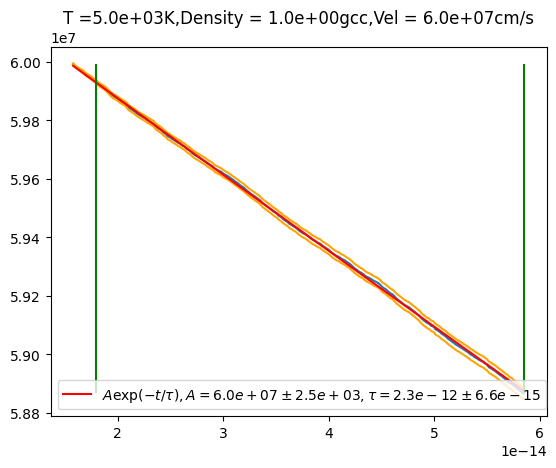

4 3
60000000.0
[[1.0000000e+02 1.8343610e-16 9.9847624e+04 9.9863451e+04 9.5938787e+04
  1.9353937e-05 8.9735020e-06 1.0380435e-05 1.9417708e+13 1.3911130e+08
  1.8343610e-18 7.6086890e+12 1.9321600e-19]
 [2.0000000e+02 3.6687219e-16 9.9747532e+04 9.9759652e+04 9.6765970e+04
  1.9391964e-05 9.0219343e-06 1.0370030e-05 1.9425602e+13 1.3911130e+08
  1.8343610e-18 7.6086890e+12 1.9321600e-19]
 [3.0000000e+02 5.5030829e-16 9.9709244e+04 9.9717190e+04 9.7771801e+04
  1.9425388e-05 9.0593394e-06 1.0366049e-05 1.9430271e+13 1.3911130e+08
  1.8343610e-18 7.6086890e+12 1.9321600e-19]
 [4.0000000e+02 7.3374439e-16 1.0008782e+05 1.0009264e+05 9.8932560e+04
  1.9461377e-05 9.0559708e-06 1.0405407e-05 1.9448177e+13 1.3911130e+08
  1.8343610e-18 7.6086890e+12 1.9321600e-19]
 [5.0000000e+02 9.1718048e-16 1.0040749e+05 1.0041020e+05 9.9780980e+04
  1.9460011e-05 9.0213697e-06 1.0438641e-05 1.9445205e+13 1.3911130e+08
  1.8343610e-18 7.6086890e+12 1.9321600e-19]
 [6.0000000e+02 1.1006166e-15 1.0041608e

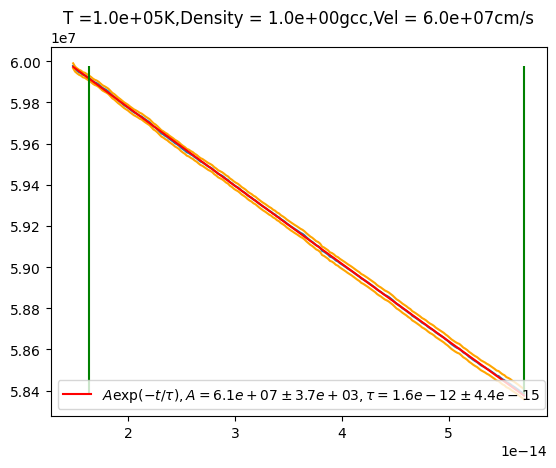

In [18]:
gccarr =  np.array([1e-5,1,1e-5,1])
Tarr = np.array([5000,5000,1e5,1e5])
Z1arr = np.array([0.16,0.65,0.93,0.68])
Z2arr = np.array([0.26,3.82,4.27,3.81])
folder = "../dataarchive/"+run+"np/"
from scipy.optimize import curve_fit

results = -1*np.ones((4,len(velarr),6)) #4 cases, velocities, A, Aerr, tau, tauerr, start time, end time
def exp(time,m,b):
    return b*np.exp(-time/m)
for i in range(len(velarr)):
    for j in range(len(casearr)):
        if  [i,j] not in [[0,0],[0,1],[0,2],[1,2],[3,2],[4,2],[5,0],[5,1],[5,2],[5,3]]:
            print(i,j)
            vel = velarr[i]
            print(vel)
            case = casearr[j]
            log = np.loadtxt(folder+"log_v{:.1}_c{}.np".format(vel,case))
            force = np.loadtxt(folder+"force_v{:.1}_c{}.np".format(vel,case))
            print(log)
            time = force[81:,-1]
            data = force[81:,:-1]
            plt.title("T ={:.1e}K,Density = {:.1e}gcc,Vel = {:.1e}cm/s".format(Tarr[j],gccarr[j],velarr[i]))
            mean = np.mean(data,axis=1)

            starti = min(np.argmin(np.abs(0.999*mean[0]-mean)),int(0.1*len(mean)))
            print(starti)
            endi = max(np.argmin(np.abs(0.8*mean[0]-mean)),int(0.15*len(mean)))
            std = np.std(data,axis=1)/math.sqrt(2000)
            dt0 = time[-1]-time[0]
            plt.plot(time,mean)
            print(endi)
            popt, pcov = curve_fit(exp,time[starti:endi],mean[starti:endi],sigma =std[starti:endi],p0=[dt0,mean[0]*math.exp(-time[0]/dt0)],absolute_sigma=True)
            errors = np.sqrt(np.diag(pcov))
            results[j,i,:] = [popt[1],errors[1],popt[0],errors[0],time[starti],time[endi]]
            plt.plot(time,mean+std,color="orange")
            plt.plot(time,mean-std,color="orange")
            plt.plot(time,exp(time,popt[0],popt[1]),color="red",label=r"$A\exp(-t/\tau),A = {:.1e}\pm{:.1e}, \tau = {:.1e}\pm {:.1e}$".format(popt[1],errors[1],popt[0],errors[0]))
            plt.vlines([time[starti],time[endi]],ymin=np.min(mean),ymax=np.max(mean),color="green")
            plt.legend()
            plt.show()
np.save("results",results)

$$ v = A \exp(-t/\tau)$$
$$ a = -v/\tau$$
$$(\Delta v)^2 = \exp(-2t/\tau) (\Delta A^2) + \frac{t^2A^2}{\tau^4} \exp(-2t/\tau) (\Delta \tau^2)$$
$$(\Delta v)^2 = \frac{v^2}{A^2} (\Delta A^2) + \frac{t^2v^2}{\tau^4}  (\Delta \tau^2)$$
$$(\frac{\Delta a}{a})^2 = (\frac{\Delta v}{v})^2 + (\frac{\Delta \tau}{\tau})^2$$

# Overall Plot

C:\Users\shaoq\AppData\Local\Temp\ipykernel_27896\2017327531.py:57: ComplexWarning: Casting complex values to real discards the imaginary part
  result[i] = 2*mu*n*np.sum(ccs*vrel*np.abs(vrel)*frel(vrel,vb,T))/np.sum(frel(vrel,vb,T))


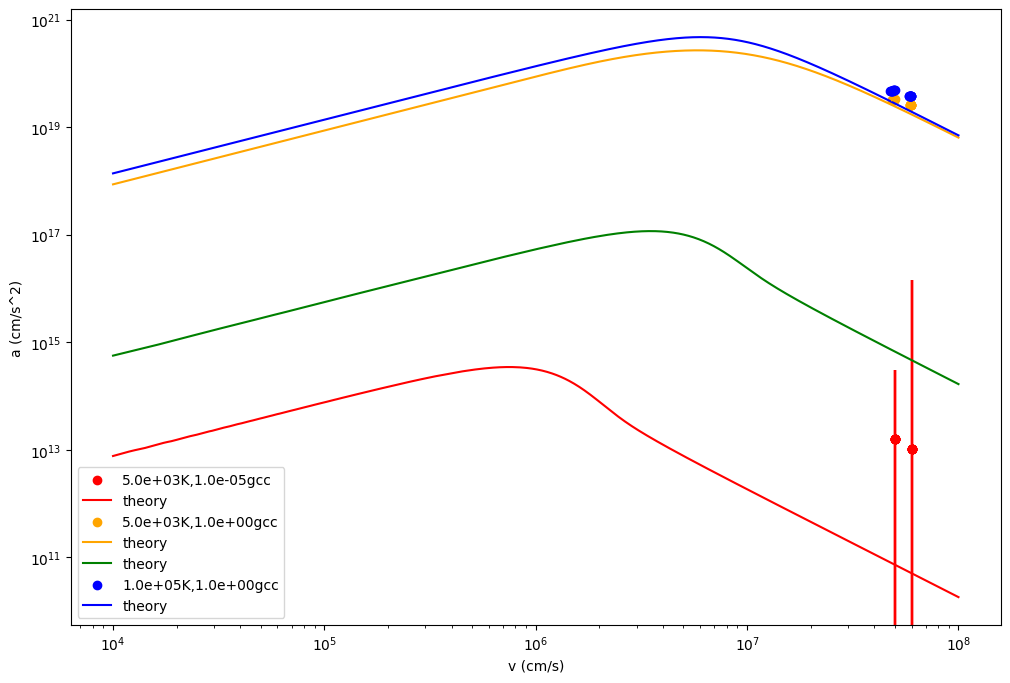

In [17]:
import scipy as scp
NA = 6.022e23
pi = 3.1415926535
me = 9.11e-31 #electron mass
ms = 28.0855*0.001/NA #silicon mass kg
mh = 1.008*0.001/NA
mu = ms*mh/(ms+mh)
qe = 1.6e-19
hbar = 6.626e-34
kb = 1.38e-23
e0 =  8.854e-12
#exp(-Ax)/x = B
#x = W(a/b)/a
Z1arr = np.array([0.16,0.65,0.93,0.68])
Z2arr = np.array([0.26,3.82,4.27,3.81])
def ccs2(vrel,T,gcc,z1=0.648,z2=3.84):# use kinetic energy difference
    NA = 6.022e23
    pi = 3.1415926535
    me = 9.11e-31 #electron mass
    ms = 28.0855*0.001/NA
    mh = 1.008*0.001/NA
    mu = ms*mh/(ms+mh)
    qe = 1.6e-19
    hbar = 6.626e-34
    kb = 1.38e-23
    e0 =  8.854e-12
    vcom =  mh*vrel/(mh+ms)
    ne =1e6* NA*z1*gcc/1.008
    ve = np.sqrt(3*kb*T/me)
    wp = np.sqrt(ne*(qe**2)/(me*e0))
    lD = ve/wp
    Tf = ((3*ne*(pi**2))**(2/3))*(hbar**2)/(2*me*kb)
    lS = lD*np.power(1+(2*Tf/(3*T)),1/4)
    k0 = 1/lS
    Aarr = (qe**2)*z1*z2/(4*pi*e0)
    #kinetic energy available is velocity relative to COM
    Barr = 0.5*mh*((vrel-vcom)**2)+0.5*ms*((vcom)**2)
    Carr = Barr/Aarr
    rc = scp.special.lambertw(k0/Carr)/k0
    return pi*rc**2


def frel(vrel,vb,T):
    mu = ms*mh/(ms+mh)
    return np.sqrt(mu/(2*pi*kb*T))*np.exp(-mu*np.square(vrel-vb)/(2*kb*T))

def FDint(vbarr,A,T,gcc,zh,zs): #return drag force in newtons, input velocity in meters per second
    mu = ms*mh/(ms+mh)
    n =1e6* NA*gcc/1.008
    std = np.sqrt(kb*T/mu)
    result = np.zeros(len(vbarr))
    for i in range(len(vbarr)):
        vb = vbarr[i]
        vrel = np.linspace(vb-8*std,vb+8*std,2000)
        dvrel = vrel[1]-vrel[0]
        ccs = A*ccs2(vrel,T,gcc,zh,zs)
        result[i] = 2*mu*n*np.sum(ccs*vrel*np.abs(vrel)*frel(vrel,vb,T))/np.sum(frel(vrel,vb,T))
    return result
results = np.load("results.npy")
gccarr =  np.array([1e-5,1,1e-5,1])
Tarr = np.array([5000,5000,1e5,1e5])
plt.figure(figsize=(12,8))
def exp(time,tau,A):
    return A*np.exp(-time/tau)
colors=["red","orange","green","blue"]
labelled = [False,False,False,False]
xarr = np.logspace(4,8,1000)
for i in range(4):

    for j in range(3,len(velarr)):
        if results[i,j,4] !=-1:
            casen = casearr[i]
            vel = velarr[j]
            startt = results[i,j,4]
            endt = results[i,j,5]
            tarr = np.linspace(startt,endt,10)
            A = results[i,j,0]
            eA = results[i,j,1]
            tau = results[i,j,2]
            etau = results[i,j,3]
            varr = exp(tarr,tau,A)
            aarr = varr/tau
            verr = np.sqrt(np.square(varr*eA/A)+np.square(tarr*varr*etau/np.square(tau)))
            aerr = aarr*np.sqrt(np.square(verr/varr)+np.square(etau/tau))

            if labelled[i]:
                plt.scatter(varr,aarr,color=colors[i])
                plt.errorbar(varr,aarr,xerr=verr,yerr=aerr,color=colors[i])
            else:
                plt.scatter(varr,aarr,color=colors[i],label="{:.1e}K,{:.1e}gcc".format(Tarr[i],gccarr[i]))
                plt.errorbar(varr,aarr,xerr=verr,yerr=aerr,color=colors[i])
                labelled[i] = True
    plt.plot(xarr,100*np.abs(FDint(xarr/100,1,Tarr[i],gccarr[i],Z1arr[i],Z2arr[i]))/ms,color=colors[i],label="theory")
plt.legend()
plt.xscale("log")
plt.yscale("log")
plt.xlabel("v (cm/s)")
plt.ylabel("a (cm/s^2)")
plt.show()

# Fit Theory

C:\Users\shaoq\AppData\Local\Temp\ipykernel_10424\2668801564.py:60: ComplexWarning: Casting complex values to real discards the imaginary part
  result[i] = 2*mu*n*np.sum(ccs*vrel*np.abs(vrel)*frel(vrel,vb,T))/np.sum(frel(vrel,vb,T))


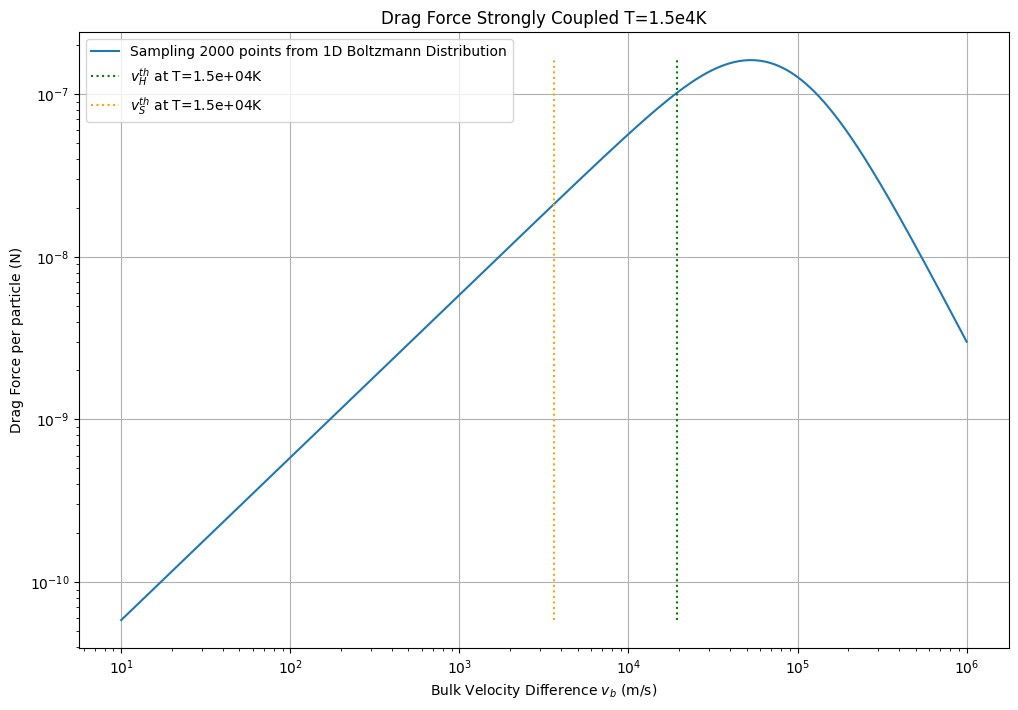

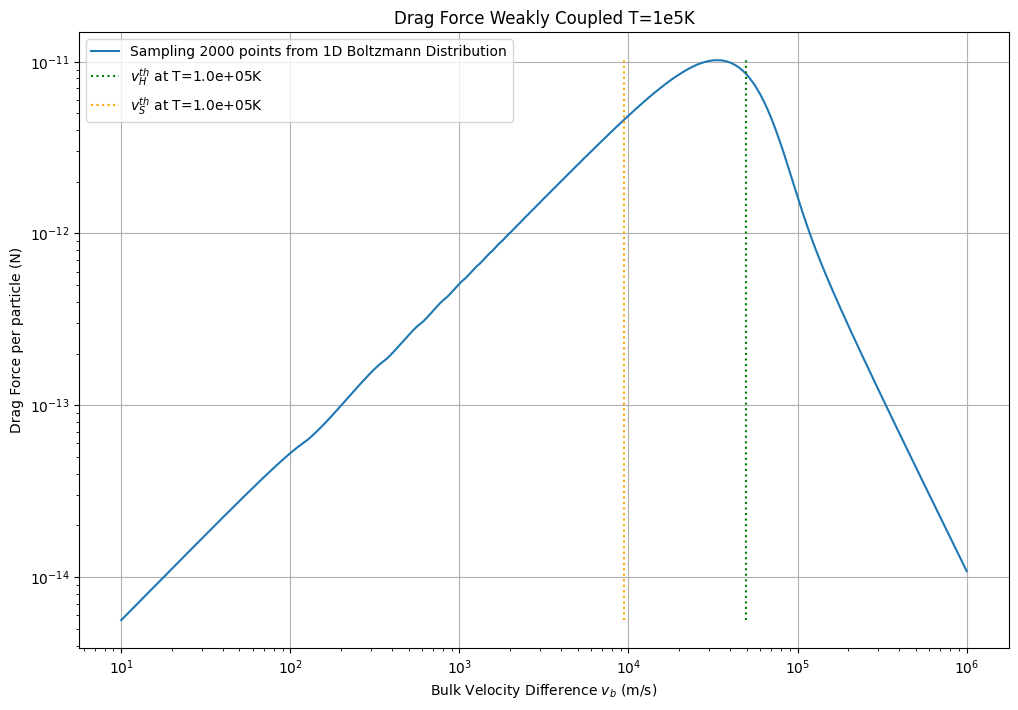

In [ ]:
import numpy as np
import scipy as scp
import numpy as np
import math as math
import matplotlib.pyplot as plt
from matplotlib import cm



CD=1
Tarr = np.array([15000,100000])
gccarr = [1,1e-6]
zharr = [0.648,0.955]
zsarr = [3.84,4.91]
varr = np.logspace(1,6,10000)


CD=1
vthermh = np.sqrt(3*kb*Tarr/mh)
vtherms = np.sqrt(3*kb*Tarr/ms)
titlearr = ["Drag Force Strongly Coupled T=1.5e4K","Drag Force Weakly Coupled T=1e5K"]
for i in range(len(Tarr)):
    plt.figure(figsize=(12,8))
    plt.xlabel(r"Bulk Velocity Difference $v_b$ (m/s)")
    plt.ylabel("Drag Force per particle (N)")
    plt.title(titlearr[i])
    T = Tarr[i]
    gcc = gccarr[i]
    zh=zharr[i]
    zs=zsarr[i]
    # print(np.min(dp(varr,T)))
    force2 = FDint(varr,CD,T,gcc,zh,zs)
    plt.plot(varr,np.abs(force2),label=r"Sampling 2000 points from 1D Boltzmann Distribution")
    plt.vlines(vthermh[i],ymin=np.min(np.abs(force2)),ymax = np.max(np.abs(force2)),ls=":",label=r"$v^{{th}}_H$ at T={:.1e}K".format(T),color="green")
    plt.vlines(vtherms[i],ymin=np.min(np.abs(force2)),ymax = np.max(np.abs(force2)),ls=":",label=r"$v^{{th}}_S$ at T={:.1e}K".format(T),color="orange")
    plt.xscale("log")
    plt.yscale("log")
    plt.grid()
    plt.legend()
    plt.show()

